### Problem Framing

The objective of this project is to predict the **next year's CO₂ emissions** for a country using historical emission data and engineered features.

Given the feature values (**X**) for a country in year **Y**, the model predicts the CO₂ emissions (**y**) for year **Y+1**. The target variable is **`co2`**, while the input features include variables such as year, CO₂ per capita, rolling mean, lag features, year-over-year percentage change, and GHG intensity.

Since the target variable is a continuous numerical value, this is a **supervised regression** problem. Supervised learning is appropriate because the dataset contains both the input features and the known target values, allowing the model to learn the relationship between them and make future predictions.

### Train-Test Split

To evaluate the machine learning models fairly, the dataset is divided into training and testing sets using a temporal split rather than a random split.

Data from **1990 to 2018** is used for training, while data from **2019 onwards** is reserved for testing. This approach reflects real-world forecasting, where historical data is used to predict future outcomes.

Random splitting is avoided because it can introduce **data leakage**, allowing the model to learn from future observations and resulting in overly optimistic performance estimates.

In [1]:
import pandas as pd

In [3]:
ghg_features = pd.read_csv("data/ghg_features.csv")

In [4]:
ghg_features.head()


,country,year,co2,co2_per_capita,co2_5yr_rolling_mean,co2_lag1,co2_lag2,co2_lag3,co2_yoy_pct_change,ghg_intensity
0,Australia,1990,278.061,16.236,NaN,NaN,NaN,NaN,NaN,1.160174e-09
1,Australia,1991,279.437,16.103,NaN,278.061,NaN,NaN,0.494855,1.132718e-09
2,Australia,1992,284.433,16.208,NaN,279.437,278.061,NaN,1.787881,1.188721e-09
3,Australia,1993,288.780,16.294,NaN,284.433,279.437,278.061,1.528304,1.157801e-09
4,Australia,1994,293.613,16.405,284.8648,288.780,284.433,279.437,1.673592,1.049415e-09


##### Temporal Train-Test Split

To evaluate the forecasting models fairly, the dataset is divided into training and testing sets using a chronological split.

Training data consists of observations from **1990 to 2018**, while testing data contains observations from **2019 onwards**.

A temporal split is used instead of a random split because time-series forecasting should only use historical information to predict future values. Random splitting would introduce data leakage by allowing the model to learn from future observations.

In [5]:
train_data = ghg_features[
    ghg_features["year"] <= 2018
].copy()

In [6]:
test_data = ghg_features[
    ghg_features["year"] >= 2019
].copy()

In [8]:
sample_count = pd.DataFrame({
    "Training Samples": train_data["country"].value_counts().sort_index(),
    "Testing Samples": test_data["country"].value_counts().sort_index()
})

sample_count

,Training Samples,Testing Samples
country,,
Australia,29,6
Brazil,29,6
China,29,6
Germany,29,6
India,29,6
Japan,29,6
Russia,29,6
South Africa,29,6
United Kingdom,29,6


##### Observation

The dataset was successfully divided into training and testing sets using a chronological split. Each country contributes historical observations from 1990 to 2018 for training and observations from 2019 onwards for testing.

This temporal split prevents data leakage and provides a realistic evaluation of the model's ability to forecast future CO₂ emissions.

#### Naive Baseline Model

Before training machine learning models, a naive baseline model is created to provide a reference for model performance.

The baseline follows a simple persistence strategy where the predicted CO₂ emissions for the next year are assumed to be equal to the current year's emissions.

The model is evaluated using **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)**. Any machine learning model should outperform this baseline to justify its additional complexity.

In [16]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error
)

##### Creating the Target Variable

The objective of this project is to predict the **next year's CO₂ emissions** for each country.

A new target column called `target_co2` is created by shifting the `co2` column one year forward within each country. This ensures that the feature values from year **Y** are used to predict CO₂ emissions for year **Y+1**.

The final observation for each country has no corresponding next-year value, so its target becomes missing (`NaN`) and is removed before model training.

In [10]:
ghg_features["target_co2"] = (
    ghg_features
    .groupby("country")["co2"]
    .shift(-1)
)

In [11]:
ghg_features = ghg_features.dropna(
    subset=["target_co2"]
)

In [21]:
train_data = ghg_features[
    ghg_features["year"] <= 2018
].copy()

test_data = ghg_features[
    ghg_features["year"] >= 2019
].copy()

In [22]:
ghg_features[
    [
        "country",
        "year",
        "co2",
        "target_co2"
    ]
].head(50)

,country,year,co2,target_co2
0,Australia,1990,278.061,279.437
1,Australia,1991,279.437,284.433
2,Australia,1992,284.433,288.780
3,Australia,1993,288.780,293.613
4,Australia,1994,293.613,304.962
5,Australia,1995,304.962,311.851
6,Australia,1996,311.851,320.243
7,Australia,1997,320.243,334.038
8,Australia,1998,334.038,343.876
9,Australia,1999,343.876,349.898


In [13]:
ghg_features[
    [
        "country",
        "year",
        "co2",
        "target_co2"
    ]
].tail(15)

,country,year,co2,target_co2
334,United States,2009,5486.104,5669.250
335,United States,2010,5669.250,5538.973
336,United States,2011,5538.973,5331.467
337,United States,2012,5331.467,5473.436
338,United States,2013,5473.436,5531.385
339,United States,2014,5531.385,5368.497
340,United States,2015,5368.497,5245.362
341,United States,2016,5245.362,5195.417
342,United States,2017,5195.417,5361.236
343,United States,2018,5361.236,5235.912


##### Evaluating the Naive Baseline Model

The naive baseline model assumes that the CO₂ emissions for the next year will be the same as the current year's emissions.

For each country, the baseline predictions are compared with the actual next-year CO₂ emissions using **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)**. These metrics provide a benchmark against which the machine learning models will later be compared.

In [33]:
baseline_results = []

for country in test_data["country"].unique():

    country_data = test_data[
        test_data["country"] == country
    ]

    actual = country_data["target_co2"]

    predicted = country_data["co2"]

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = root_mean_squared_error(
        actual,
        predicted
    )

    baseline_results.append({
        "Country": country,
        "Baseline MAE": mae,
        "Baseline RMSE": rmse
    })

baseline_results = pd.DataFrame(baseline_results)

baseline_results

,Country,Baseline MAE,Baseline RMSE
0,Australia,6.7002,8.887581
1,Brazil,19.7412,26.352645
2,China,315.1044,344.121882
3,Germany,39.5944,46.431112
4,India,191.8378,197.188147
5,Japan,36.5260,39.830915
6,Russia,44.2358,50.307134
7,South Africa,12.2652,17.077892
8,United Kingdom,18.8426,23.468566
9,United States,212.5380,292.332458


###### Observation

The naive baseline model was evaluated for each of the ten project countries using MAE and RMSE. The results show that prediction errors vary across countries depending on the magnitude and variability of their CO₂ emissions.

For every country, RMSE is higher than MAE because RMSE gives greater weight to larger prediction errors. These baseline results will serve as a benchmark for evaluating the performance of the Linear Regression and Random Forest models in the following sections.

##### Actual vs Predicted CO₂ Emissions

To visually evaluate the performance of the naive baseline model, the actual next-year CO₂ emissions are compared with the baseline predictions for three selected countries.

The line plots show how closely the baseline model follows the actual CO₂ emission trend over time. Differences between the two lines represent the prediction errors made by the baseline model.

In [35]:
countries_to_plot = [
    "China",
    "India",
    "United States"
]

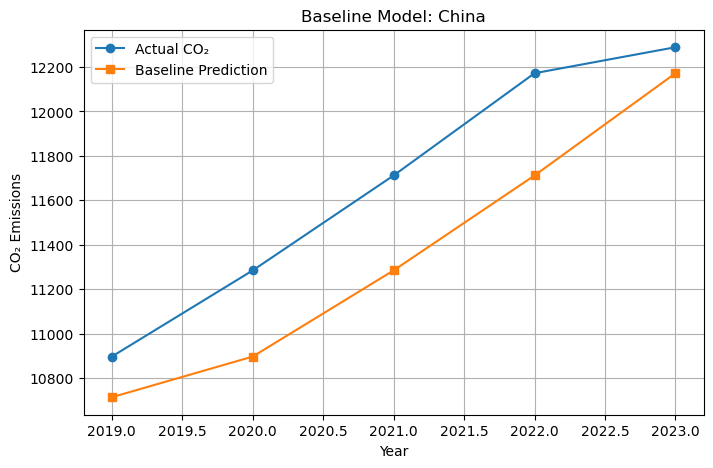

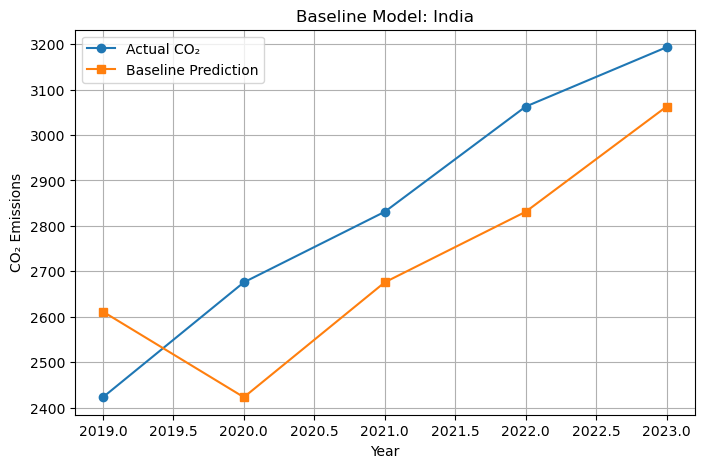

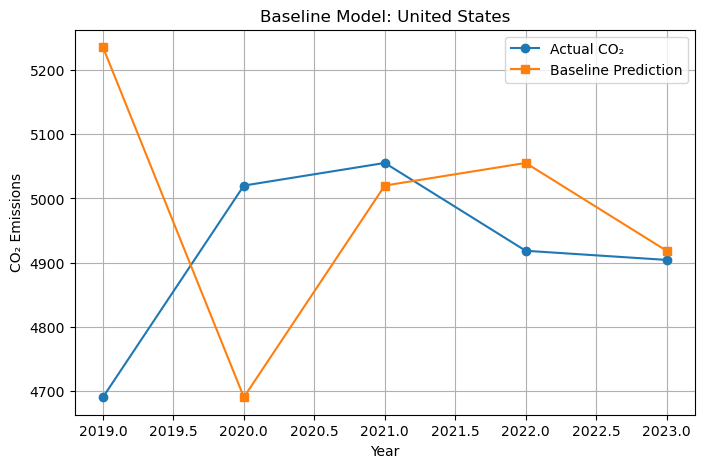

In [36]:
import matplotlib.pyplot as plt

countries_to_plot = [
    "China",
    "India",
    "United States"
]

for country in countries_to_plot:

    country_data = test_data[
        test_data["country"] == country
    ]

    plt.figure(figsize=(8,5))

    plt.plot(
        country_data["year"],
        country_data["target_co2"],
        marker="o",
        label="Actual CO₂"
    )

    plt.plot(
        country_data["year"],
        country_data["co2"],
        marker="s",
        label="Baseline Prediction"
    )

    plt.title(f"Baseline Model: {country}")

    plt.xlabel("Year")

    plt.ylabel("CO₂ Emissions")

    plt.legend()

    plt.grid(True)

    plt.show()

##### Observation

The baseline model generally follows the overall emission trend but consistently lags behind the actual values because it assumes that the next year's CO₂ emissions will be identical to the current year's emissions.

For countries with relatively stable emission patterns, such as Australia, the baseline performs reasonably well. However, for countries with larger year-to-year fluctuations, such as the United States and China, the prediction errors are greater because the baseline model cannot anticipate sudden increases or decreases in emissions.

These plots highlight the limitations of the naive baseline model and demonstrate the need for more sophisticated machine learning models capable of learning complex temporal relationships.

In [38]:
from sklearn.linear_model import LinearRegression

##### Linear Regression Model

A Linear Regression model is trained to predict the next year's CO₂ emissions using the engineered features created in Week 2.

The model learns the relationship between the input features and the target variable by estimating coefficients that minimize the prediction error on the training data. The trained model is then evaluated on the test dataset using MAE and RMSE for each country.

The learned coefficients are also examined to understand which features have the greatest influence on the predicted CO₂ emissions.

In [39]:
features = [
    "year",
    "co2",
    "co2_per_capita",
    "co2_5yr_rolling_mean",
    "co2_lag1",
    "co2_lag2",
    "co2_lag3",
    "co2_yoy_pct_change",
    "ghg_intensity"
]

In [57]:
model_data = ghg_features.dropna(
    subset=features + ["target_co2"]
).copy()

In [58]:
train_data = model_data[
    model_data["year"] <= 2018
].copy()

test_data = model_data[
    model_data["year"] >= 2019
].copy()

In [59]:
X_train = train_data[features]

y_train = train_data["target_co2"]

X_test = test_data[features]

y_test = test_data["target_co2"]

In [60]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(250, 9)
(250,)
(40, 9)
(40,)


In [61]:
lr_model = LinearRegression()

In [62]:
lr_model.fit(
    X_train,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
lr_predictions = lr_model.predict(
    X_test
)

##### Evaluating the Linear Regression Model

The trained Linear Regression model is evaluated on the test dataset for each country.

The predicted values are compared with the actual next-year CO₂ emissions using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [64]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error
)

lr_results = []

for country in test_data["country"].unique():

    country_data = test_data[
        test_data["country"] == country
    ]

    X_country = country_data[features]

    y_actual = country_data["target_co2"]

    y_pred = lr_model.predict(X_country)

    mae = mean_absolute_error(
        y_actual,
        y_pred
    )

    rmse = root_mean_squared_error(
        y_actual,
        y_pred
    )

    lr_results.append({
        "Country": country,
        "LR MAE": mae,
        "LR RMSE": rmse
    })

lr_results = pd.DataFrame(lr_results)

lr_results

,Country,LR MAE,LR RMSE
0,Australia,27.036408,27.928804
1,Brazil,27.945234,32.116456
2,China,131.063361,137.381203
3,Germany,39.309512,43.093958
4,India,177.975527,199.494428
5,Japan,35.154724,38.106028
6,Russia,56.857143,64.873197
7,South Africa,14.687995,15.992982
8,United Kingdom,19.990089,25.233003
9,United States,293.630418,374.592585


##### Actual vs Predicted CO₂ Emissions

The actual next-year CO₂ emissions are compared with the Linear Regression predictions for China, India, and the United States.

The closer the predicted line is to the actual line, the better the model captures the emission trend.

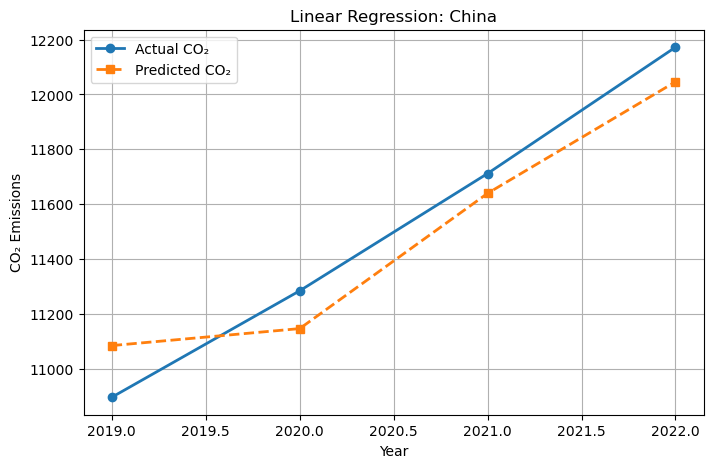

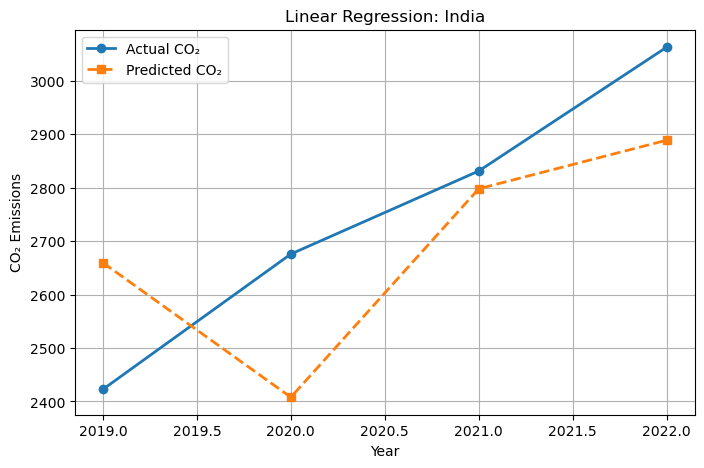

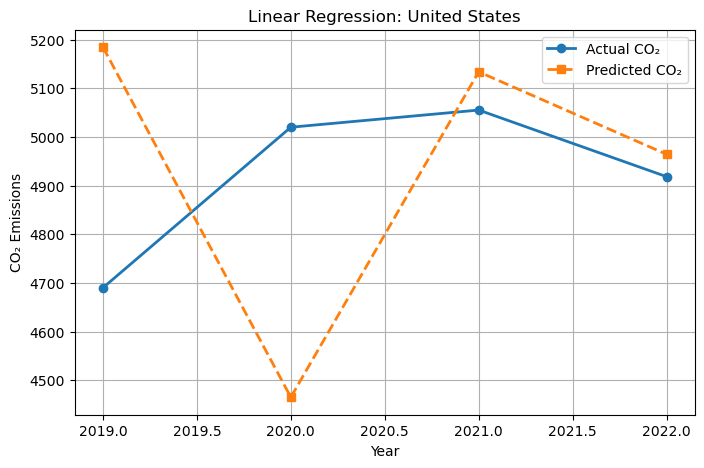

In [65]:
import matplotlib.pyplot as plt

countries_to_plot = [
    "China",
    "India",
    "United States"
]

for country in countries_to_plot:

    country_data = test_data[
        test_data["country"] == country
    ]

    X_country = country_data[features]

    y_pred = lr_model.predict(X_country)

    plt.figure(figsize=(8,5))

    plt.plot(
        country_data["year"],
        country_data["target_co2"],
        marker="o",
        linewidth=2,
        label="Actual CO₂"
    )

    plt.plot(
        country_data["year"],
        y_pred,
        marker="s",
        linestyle="--",
        linewidth=2,
        label="Predicted CO₂"
    )

    plt.title(f"Linear Regression: {country}")
    plt.xlabel("Year")
    plt.ylabel("CO₂ Emissions")
    plt.legend()
    plt.grid(True)
    plt.show()

In [66]:
lr_results

,Country,LR MAE,LR RMSE
0,Australia,27.036408,27.928804
1,Brazil,27.945234,32.116456
2,China,131.063361,137.381203
3,Germany,39.309512,43.093958
4,India,177.975527,199.494428
5,Japan,35.154724,38.106028
6,Russia,56.857143,64.873197
7,South Africa,14.687995,15.992982
8,United Kingdom,19.990089,25.233003
9,United States,293.630418,374.592585


In [67]:
baseline_results

,Country,Baseline MAE,Baseline RMSE
0,Australia,6.7002,8.887581
1,Brazil,19.7412,26.352645
2,China,315.1044,344.121882
3,Germany,39.5944,46.431112
4,India,191.8378,197.188147
5,Japan,36.5260,39.830915
6,Russia,44.2358,50.307134
7,South Africa,12.2652,17.077892
8,United Kingdom,18.8426,23.468566
9,United States,212.5380,292.332458


##### Observation

The Linear Regression model did not outperform the baseline model for every country. It achieved lower prediction errors for countries with clearer linear emission trends, such as China, but the baseline model remained more accurate for countries with relatively stable or irregular emission patterns, such as Australia and the United States.

These results highlight that model performance depends on the characteristics of the data, and a more complex model does not always guarantee better predictions.

In [68]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr_model.coef_
})

coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient,Absolute Coefficient
8,ghg_intensity,7.996517e+09,7.996517e+09
7,co2_yoy_pct_change,-3.982301e+00,3.982301e+00
2,co2_per_capita,-3.832581e+00,3.832581e+00
1,co2,1.472365e+00,1.472365e+00
0,year,-9.791872e-01,9.791872e-01
4,co2_lag1,-6.964964e-01,6.964964e-01
3,co2_5yr_rolling_mean,6.153213e-01,6.153213e-01
6,co2_lag3,-4.920156e-01,4.920156e-01
5,co2_lag2,1.100617e-01,1.100617e-01


##### Interpretation of Model Coefficients

The Linear Regression model assigns a coefficient to each input feature, indicating how that feature influences the predicted CO₂ emissions while keeping the other features constant.

The current year's CO₂ emissions (`co2`) have a positive coefficient, suggesting that higher current emissions generally lead to higher predicted emissions in the following year. The 5-year rolling mean also contributes positively, indicating that long-term historical trends are useful for forecasting.

Some features, such as `co2_yoy_pct_change`, `co2_per_capita`, and the lag features, have negative coefficients. These signs should be interpreted carefully because several input features are correlated with one another. In multiple linear regression, correlated features can produce negative coefficients even when they are positively related to the target individually.

The very large coefficient for `ghg_intensity` is mainly due to the feature's small numerical scale rather than indicating that it is the most important predictor. Since the features are not standardized, coefficient magnitudes should not be directly compared across different units of measurement.

In [69]:
from sklearn.ensemble import RandomForestRegressor

##### Random Forest Regressor

A Random Forest Regressor is an ensemble learning algorithm that combines the predictions of multiple decision trees to improve prediction accuracy and reduce overfitting.

Unlike Linear Regression, Random Forest can capture complex non-linear relationships between the engineered features and future CO₂ emissions. The model is trained using the same training dataset and evaluated on the test dataset using MAE and RMSE.

In [70]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

##### Training the Random Forest Regressor

The Random Forest Regressor is trained using the same training dataset as the Linear Regression model.

The model builds 100 decision trees and combines their predictions by averaging them, allowing it to capture complex, non-linear relationships between the engineered features and future CO₂ emissions.

In [71]:
rf_model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [73]:
rf_predictions = rf_model.predict(
    X_test
)

In [80]:
rf_predictions[:10]

array([  411.76926,   409.30888,   388.28837,   378.13659,   474.18558,
         462.5722 ,   486.76307,   469.34749, 10463.81146, 10441.63948])

In [75]:
y_pred = rf_model.predict(X_country)

##### Evaluating the Random Forest Model

The Random Forest Regressor is evaluated on the test dataset for each country. The predicted CO₂ emissions are compared with the actual next-year CO₂ emissions using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

The results are calculated separately for each country to compare the performance of the Random Forest model with the Baseline and Linear Regression models.

In [77]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error
)

rf_results = []

for country in test_data["country"].unique():

    country_data = test_data[
        test_data["country"] == country
    ]

    X_country = country_data[features]

    y_actual = country_data["target_co2"]

    y_pred = rf_model.predict(X_country)

    mae = mean_absolute_error(
        y_actual,
        y_pred
    )

    rmse = root_mean_squared_error(
        y_actual,
        y_pred
    )

    rf_results.append({
        "Country": country,
        "RF MAE": mae,
        "RF RMSE": rmse
    })

rf_results = pd.DataFrame(rf_results)

rf_results

,Country,RF MAE,RF RMSE
0,Australia,11.112230,12.892983
1,Brazil,20.381490,22.915405
2,China,1061.647585,1163.738791
3,Germany,81.481080,86.868123
4,India,115.726503,146.684899
5,Japan,91.559447,94.326490
6,Russia,33.610298,36.662727
7,South Africa,15.531923,18.536612
8,United Kingdom,48.447217,48.807921
9,United States,347.458805,371.901873


##### Feature Importance

Random Forest estimates the importance of each feature based on how much it reduces prediction error across all decision trees.

Features with higher importance values contribute more to the model's predictions, while features with lower importance values have less influence.

Unlike Linear Regression coefficients, feature importance values are always non-negative and indicate the relative usefulness of each feature.

In [83]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

feature_importance

,Feature,Importance
7,co2_yoy_pct_change,0.000447
0,year,0.000852
2,co2_per_capita,0.001509
8,ghg_intensity,0.002267
6,co2_lag3,0.125723
5,co2_lag2,0.192433
4,co2_lag1,0.195117
1,co2,0.239961
3,co2_5yr_rolling_mean,0.241691


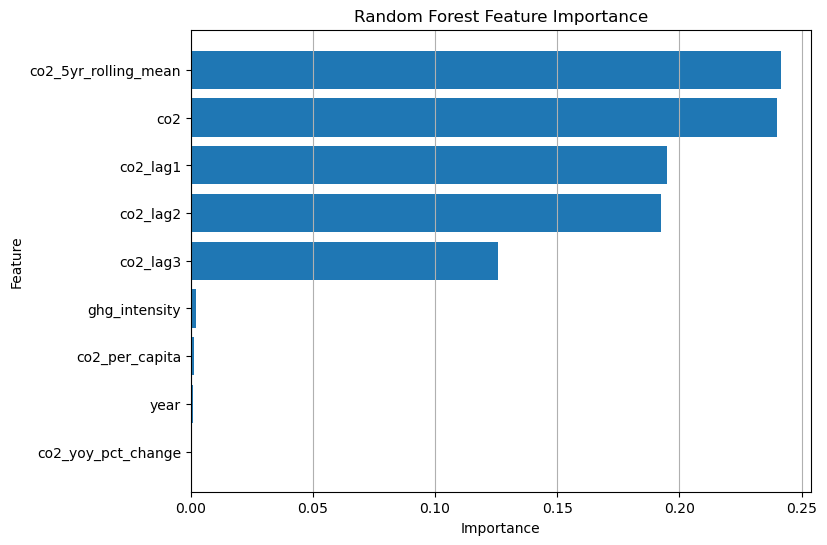

In [84]:
plt.figure(figsize=(8,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.grid(axis="x")

plt.show()

##### Interpretation of Feature Importance

The Random Forest model identified the 5-year rolling mean of CO₂ emissions (`co2_5yr_rolling_mean`) as the most important feature, closely followed by the current year's CO₂ emissions (`co2`). This indicates that both long-term emission trends and the current emission level are the strongest predictors of future CO₂ emissions.

The lag features (`co2_lag1`, `co2_lag2`, and `co2_lag3`) also contributed substantially, highlighting the importance of historical emission patterns in forecasting.

Features such as `ghg_intensity`, `co2_per_capita`, `year`, and `co2_yoy_pct_change` had very low importance, suggesting that they contributed relatively little to the model's predictions compared with the historical CO₂ features.

##### Model Comparison

The performance of the Baseline, Linear Regression, and Random Forest models is compared using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

For each country, the model with the lowest MAE is selected as the best-performing model. This comparison helps determine which modelling approach is most suitable for forecasting CO₂ emissions.

In [85]:
comparison_table = baseline_results.merge(
    lr_results,
    on="Country"
)

comparison_table = comparison_table.merge(
    rf_results,
    on="Country"
)

comparison_table

,Country,Baseline MAE,Baseline RMSE,LR MAE,LR RMSE,RF MAE,RF RMSE
0,Australia,6.7002,8.887581,27.036408,27.928804,11.112230,12.892983
1,Brazil,19.7412,26.352645,27.945234,32.116456,20.381490,22.915405
2,China,315.1044,344.121882,131.063361,137.381203,1061.647585,1163.738791
3,Germany,39.5944,46.431112,39.309512,43.093958,81.481080,86.868123
4,India,191.8378,197.188147,177.975527,199.494428,115.726503,146.684899
5,Japan,36.5260,39.830915,35.154724,38.106028,91.559447,94.326490
6,Russia,44.2358,50.307134,56.857143,64.873197,33.610298,36.662727
7,South Africa,12.2652,17.077892,14.687995,15.992982,15.531923,18.536612
8,United Kingdom,18.8426,23.468566,19.990089,25.233003,48.447217,48.807921
9,United States,212.5380,292.332458,293.630418,374.592585,347.458805,371.901873


In [86]:
comparison_table["Best Model"] = (
    comparison_table[
        [
            "Baseline MAE",
            "LR MAE",
            "RF MAE"
        ]
    ]
    .idxmin(axis=1)
)

In [87]:
comparison_table["Best Model"] = (
    comparison_table["Best Model"]
    .replace({
        "Baseline MAE": "Baseline",
        "LR MAE": "Linear Regression",
        "RF MAE": "Random Forest"
    })
)

comparison_table

,Country,Baseline MAE,Baseline RMSE,LR MAE,LR RMSE,RF MAE,RF RMSE,Best Model
0,Australia,6.7002,8.887581,27.036408,27.928804,11.112230,12.892983,Baseline
1,Brazil,19.7412,26.352645,27.945234,32.116456,20.381490,22.915405,Baseline
2,China,315.1044,344.121882,131.063361,137.381203,1061.647585,1163.738791,Linear Regression
3,Germany,39.5944,46.431112,39.309512,43.093958,81.481080,86.868123,Linear Regression
4,India,191.8378,197.188147,177.975527,199.494428,115.726503,146.684899,Random Forest
5,Japan,36.5260,39.830915,35.154724,38.106028,91.559447,94.326490,Linear Regression
6,Russia,44.2358,50.307134,56.857143,64.873197,33.610298,36.662727,Random Forest
7,South Africa,12.2652,17.077892,14.687995,15.992982,15.531923,18.536612,Baseline
8,United Kingdom,18.8426,23.468566,19.990089,25.233003,48.447217,48.807921,Baseline
9,United States,212.5380,292.332458,293.630418,374.592585,347.458805,371.901873,Baseline


##### Conclusion

Three forecasting approaches were evaluated for predicting next-year CO₂ emissions: a Naive Baseline model, Linear Regression, and Random Forest Regressor.

The results showed that no single model performed best for every country. Linear Regression achieved the lowest prediction error for countries with clearer linear emission trends, while the Baseline model remained competitive for countries with relatively stable emissions. Although the Random Forest model captured complex relationships and identified important predictive features, it did not consistently outperform the simpler models on this dataset.

These findings demonstrate the importance of comparing multiple models rather than assuming that a more complex algorithm will always produce the best predictions.